In [ ]:
import wandb
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import sys
import pathlib
import os
import numpy as np
from dataclasses import dataclass
from typing import Optional

from clifford.models.modules.linear import MVLinear
from clifford.models.modules.gp import SteerableGeometricProductLayer
from clifford.models.modules.mvlayernorm import MVLayerNorm
from clifford.models.modules.mvsilu import MVSiLU
from clifford.algebra.cliffordalgebra import CliffordAlgebra

from image2sphere.predictor import I2S
from image2sphere.models import ResNet
import image2sphere.pascal_dataset
from image2sphere.models import ResNet
from image2sphere.pascal_dataset import Pascal3D
from image2sphere.so3_utils import so3_healpix_grid

from src.model import MLPBaseline, TralaleroCompetitor, TralaleroTralala
from src.dataset import PascalSanityCheckDataset
from src.train_utils import train_epoch
from src.evaluation_metrics import calculate_evaluation_metrics
from src.img_to_pcd_stuff import PointCloudProcessor

from torch.utils.data import DataLoader
import open3d as o3d

%reload_ext autoreload
%autoreload 2

In [3]:
converter = PointCloudProcessor(device="mps", model_size="small")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps


In [4]:
i = 1

In [5]:
@dataclass
class configin:
    batch_size = 32
    path_to_datasets = "/Users/grigorychaykovsky/Downloads"
    device = torch.device("mps")
    sanity_check = False
dataset = PascalSanityCheckDataset(config=configin)
sample_batch = dataset[i]["img"].unsqueeze(0).to("mps")

out = converter(sample_batch)

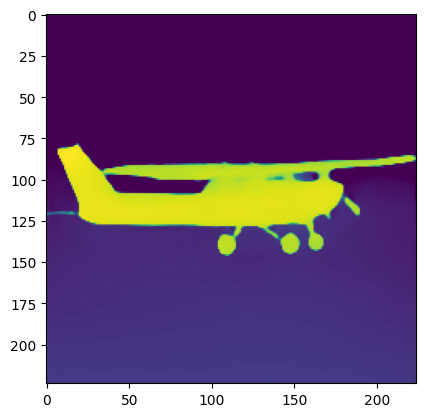

In [ ]:
from src.img_to_pcd_stuff import show_torch_img

show_torch_img(out)

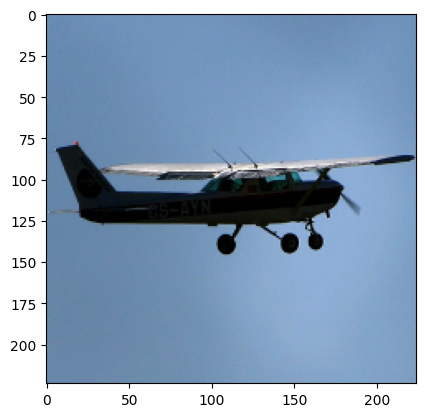

In [7]:
plt.imshow(dataset[i]["img"].permute(1, 2, 0).numpy())
plt.show()

In [ ]:

depth_map = out[0].cpu()
height, width = depth_map.shape
raw_image = dataset[i]["img"].permute(1, 2, 0).numpy()

In [ ]:
v_coords, u_coords = np.indices((height, width))

points = np.stack((v_coords, u_coords, depth_map), axis=2)

# colors = raw_image
# pcd = o3d.geometry.PointCloud()
# pcd.points = o3d.utility.Vector3dVector(points.reshape(-1, 3))
# pcd.colors = o3d.utility.Vector3dVector(colors.reshape(-1, 3))

In [ ]:
batch_size = 1
point_cloud = torch.tensor(np.stack((u_coords, v_coords, np.zeros((224, 224))), axis=2))
batched_point_clouds = np.stack([point_cloud for _ in range(batch_size)], axis=0)
batched_point_clouds.shape
# u_coords.shape
# points.shape

(1, 224, 224, 3)

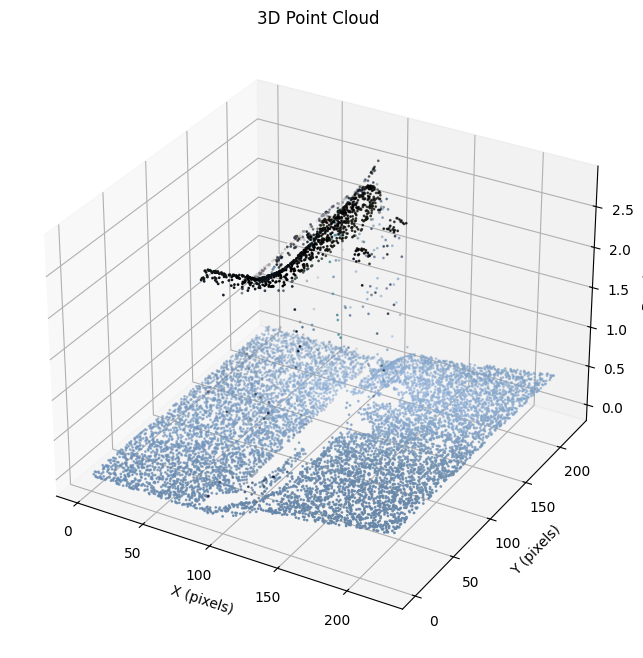

In [43]:

# o3d.visualization.draw_geometries([pcd])
converter.visualize_matplotlib(pcd)

In [ ]:

device = "mps"
model = I2P(batch_size=32).to(device)

Device set to use mps


In [71]:
model(sample_batch.to("mps")).shape

torch.Size([1, 3, 3])

In [20]:
algebra = CliffordAlgebra((1, 1, 1))
linear = MVLinear(algebra, 224 * 224, 1)

pts = torch.tensor(np.array(pcd.points)).unsqueeze(0)
pts_cl = algebra.embed_grade(pts, 1)

In [22]:
out = pts_cl
out = model.projection(out)
out = model.tralalero(out)

out.shape

torch.Size([1, 1, 8])

In [14]:
h = torch.randn(1, 8, 1)
x = torch.randn(1, 8, 3)
algebra = CliffordAlgebra((1., 1., 1.))
h_cl = algebra.embed_grade(h, 0)
x_cl = algebra.embed_grade(x, 1)
input = torch.cat([h_cl, x_cl], dim=1)

In [15]:
input.shape
# h_cl.shape

torch.Size([1, 16, 8])